(Planned)

Figure 1. Conceptual Diagram of an IMAS/IDS-based Integrated Workflow (CH 1)

Figure 2. Overall Architecture of the VEST Integrated Platform (CH 2)

Figure 3. VEST 2D Poloidal Geometry for Electromagnetic Modeling (CH 3)

<repo>/vaft/omas/__init__.py:111: RuntimeWarning: Could not infer an IMAS DD version for omas_json; using 3.41.0


(<Figure size 600x700 with 2 Axes>,
 <Axes: title={'center': 'Vacuum psi at t = 306.3 ms'}, xlabel='R [m]', ylabel='Z [m]'>)

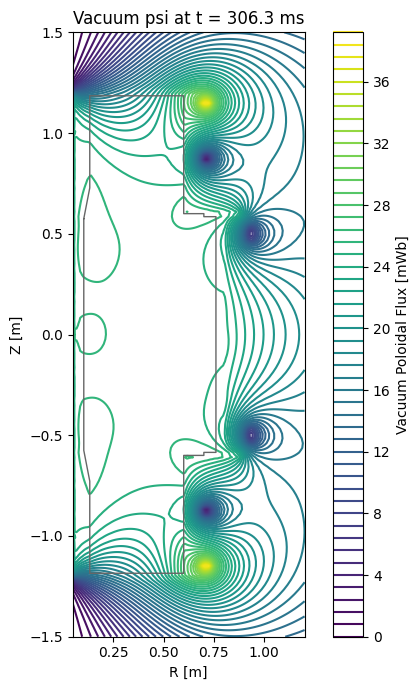

In [ ]:
import vaft
sample_path = vaft.data.sample(39915, representation="omas")
ods = vaft.omas.load(sample_path)
vaft.omas.plot_equilibrium_field_psi_vacuum(ods)

In [ ]:
from omas import *
import vaft
import matplotlib.pyplot as plt


# matplotlib 설정 개선
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20


# ods = vaft.omas.load(vaft.data.sample(39915, representation="omas"))
# vaft.omas.plot_equilibrium_field_psi_vacuum(ods)

PastedGraphic-1.png

Figure 4. Equilibrium Refinement using CHEASE

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import vaft
from vaft.data import read_geqdsk
from vaft.data.resources import data_path
from vaft.process.equilibrium import as_equilibrium, derive_global_descriptors

# Shot 48224 at 300 ms, packaged with VAFT three ways: the magnetic EFIT
# reconstruction, its CHEASE refinement on a 513x513 grid, and the kinetic-EFIT
# variant fitted with the Thomson profiles. Same shot, same instant, so the
# comparison is of the reconstructions rather than of discharges.
SHOT, TIME_MS = 48224, 300
equilibria = {
    "EFIT": data_path(f"kineticEfit/g0{SHOT}.00{TIME_MS}"),
    "CHEASE": data_path(f"kineticEfit/g0{SHOT}.00{TIME_MS}.chease"),
    "kinetic EFIT": data_path(f"kineticEfit/g0{SHOT}.00{TIME_MS}.kinetic_efit"),
}

geqdsk = {label: read_geqdsk(path) for label, path in equilibria.items()}
ods_by_label = {label: item.to_omas() for label, item in geqdsk.items()}
descriptors = {
    label: derive_global_descriptors(as_equilibrium(item))
    for label, item in geqdsk.items()
}

print(f"{'':14s} {'grid':>9s} {'Ip [kA]':>9s} {'R0 [m]':>8s} {'a [m]':>7s} "
      f"{'kappa':>7s} {'q95':>7s}  COCOS")
for label, item in geqdsk.items():
    values = descriptors[label]
    convention = as_equilibrium(item).convention
    print(f"{label:14s} {item['NW']:4d}x{item['NH']:<4d} "
          f"{item['CURRENT']/1e3:9.1f} {values['major_radius'].value:8.4f} "
          f"{values['minor_radius'].value:7.4f} {values['elongation'].value:7.4f} "
          f"{values['q95'].value:7.3f}  {convention.identified}")

<repo>/vaft/data/eqdsk.py:1074: RuntimeWarning: q on axis is 8.07, 4.2x above its immediate neighbours (median 1.9); the toroidal flux integral carries that into rho_tor_norm. The profile is used as given -- see issue #317.


                    grid   Ip [kA]   R0 [m]   a [m]   kappa     q95  COCOS
EFIT            129x129      143.2   0.3920  0.2880  1.7448   5.827  (1, 2)
CHEASE          513x513      137.9   0.3920  0.2880  1.7448   5.825  (1, 2)
kinetic EFIT    129x129      143.2   0.3916  0.2876  1.7461   5.818  (1, 2)


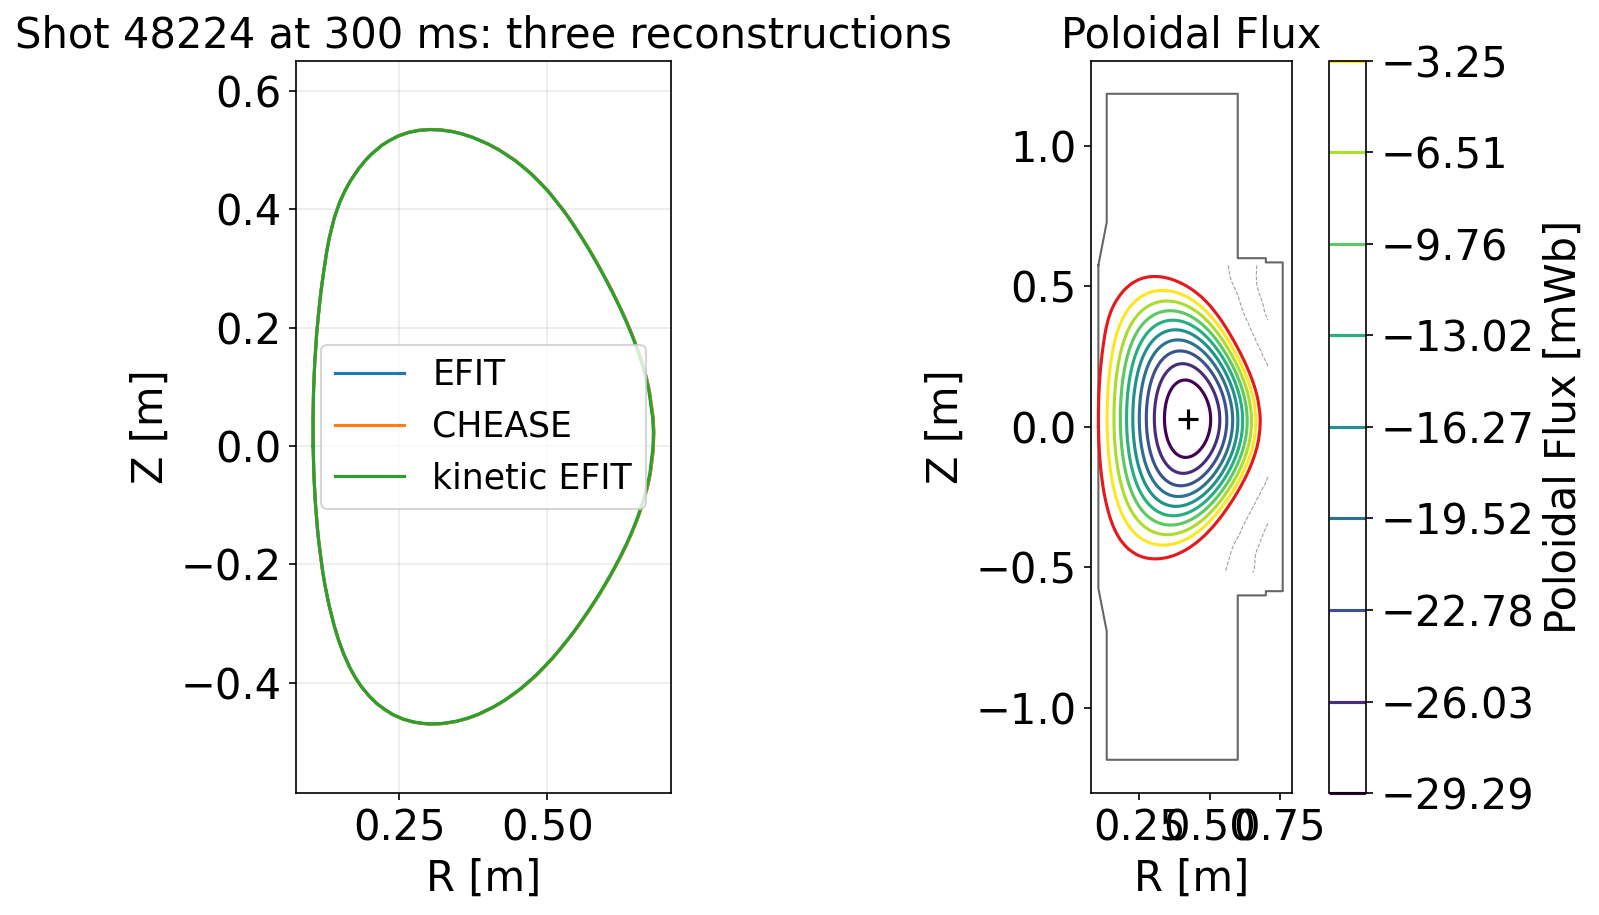

stored sgn(Ip): {'EFIT': 1, 'CHEASE': 1, 'kinetic EFIT': 1}


In [ ]:
# The boundary overlay comes from the canonical renderer, which draws every
# entry it is given; the wall and the flux map are its own layers. The three
# local helpers this cell used to define -- a wall plotter, a flux-contour
# plotter and a two-ODS comparison -- are all this call now (#64).
fig, (ax_boundary, ax_psi) = plt.subplots(1, 2, figsize=(11, 6.5))

vaft.omas.plot_equilibrium_geometry_boundary(
    list(ods_by_label.values()), label=list(ods_by_label), ax=ax_boundary,
)
ax_boundary.set_title(f"Shot {SHOT} at {TIME_MS} ms: three reconstructions")

vaft.omas.plot_equilibrium_field_psi(
    ods_by_label["CHEASE"], label=["CHEASE"], ax=ax_psi,
)
fig.tight_layout()
plt.show()

# The three files share one plasma-current sign: the CHEASE refinement was made
# from this EFIT file, whose signs already follow CHEASE's COCOS-2 pattern, so
# nothing was re-signed (#885). The descriptors above carry each file's
# identified convention beside its numbers.
signs = {label: int(np.sign(item["CURRENT"])) for label, item in geqdsk.items()}
print("stored sgn(Ip):", signs)

Figure 5. Kinetic Profile Reconstruction Process

Figure 6. Comprehensive Analysis of a Representative Discharge (e.g., Shot #41660)

In [ ]:
print('Skipped external VEST_tools / /srv ODS merge section: required files are not available in this environment.')
# The downstream cells work from the packaged EFIT reconstruction instead.
ods = ods_by_label["EFIT"].copy()

Skipped external VEST_tools / /srv ODS merge section: required files are not available in this environment.


Skipped external diagnostics/eddy/CHEASE ODS update section; using local GEQDSK-derived ODS instead.


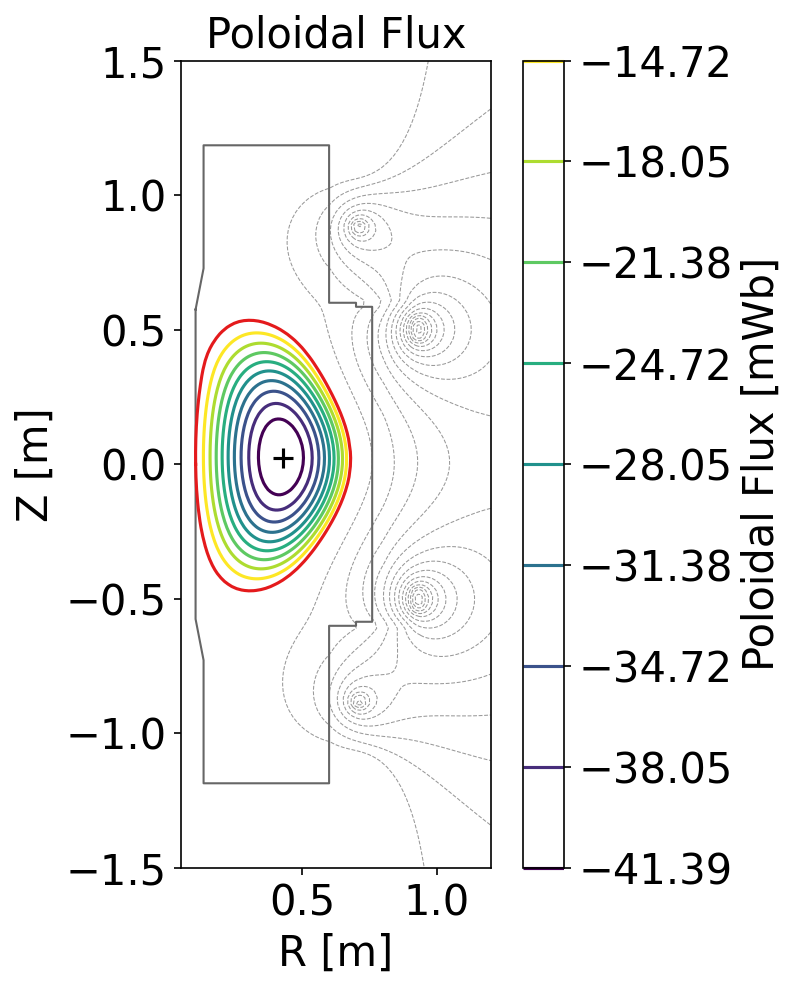

In [ ]:
print('Skipped external diagnostics/eddy/CHEASE ODS update section; using local GEQDSK-derived ODS instead.')
vaft.omas.plot_equilibrium_field_psi(ods)
plt.show()


Figure 7. Statistical Distribution of Key Operational Parameters

omas_history_new.xlsx: 2257 shots, 38000-45767
  with a plasma current above 1 kA: 2072


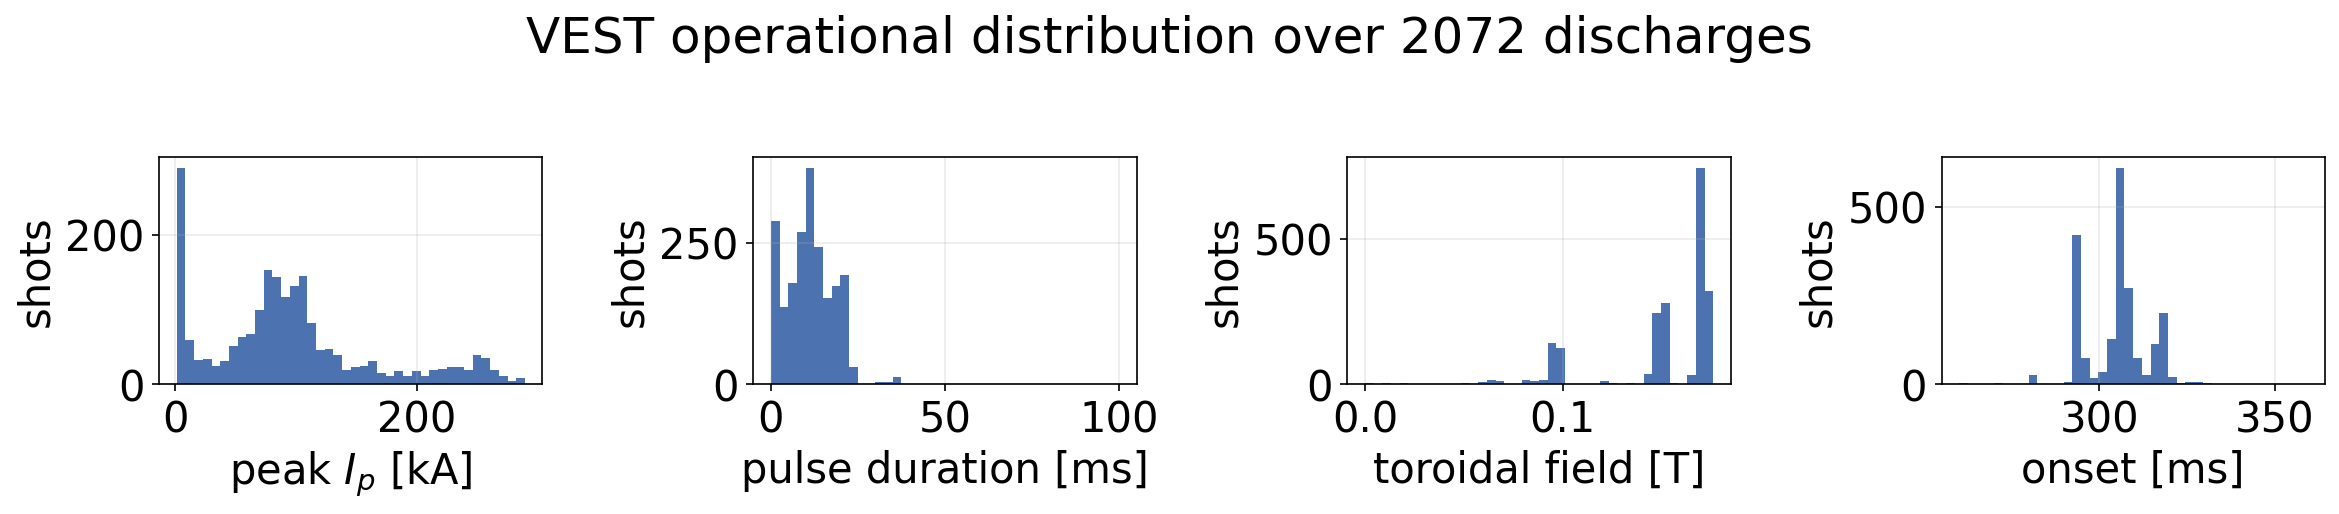

       max_plasma_current  pulse_duration  toroidal_field  plasma_onset_time
count                2072            2072            2072               2072
mean                95.76           11.25          0.1488              305.1
std                  70.5           7.181         0.03248              9.467
min                  1.01            0.08               0                260
25%                 50.95            6.36           0.147              295.4
50%                 87.09              11           0.169              306.3
75%                 121.7           15.76           0.171              309.3
max                 290.1           99.96           0.176              359.3


In [ ]:
from pathlib import Path

import pandas as pd

# The campaign history tables the summary pipeline writes. They are tracked in
# this repository, under workflow/automatic_pipeline_3_data_summary/ -- the
# cells here used to announce them as unavailable and skip.
HISTORY_DIR = Path.cwd()
if HISTORY_DIR.name == "notebooks":
    HISTORY_DIR = HISTORY_DIR.parent
HISTORY_DIR = HISTORY_DIR / "workflow" / "automatic_pipeline_3_data_summary"

operations = pd.read_excel(HISTORY_DIR / "omas_history_new.xlsx")
print(f"omas_history_new.xlsx: {len(operations)} shots, "
      f"{operations['shot'].min()}-{operations['shot'].max()}")

discharges = operations[operations["max_plasma_current"] > 1.0]
print(f"  with a plasma current above 1 kA: {len(discharges)}")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
panels = (
    ("max_plasma_current", "peak $I_p$ [kA]", None),
    ("pulse_duration", "pulse duration [ms]", None),
    ("toroidal_field", "toroidal field [T]", None),
    ("plasma_onset_time", "onset [ms]", None),
)
for ax, (column, label, _) in zip(axes, panels):
    values = discharges[column].to_numpy(dtype=float)
    ax.hist(values[np.isfinite(values)], bins=40, color="#4c72b0")
    ax.set(xlabel=label, ylabel="shots")
    ax.grid(alpha=0.25)
fig.suptitle(f"VEST operational distribution over {len(discharges)} discharges")
fig.tight_layout()
plt.show()

print(discharges[[c for c, _, _ in panels]].describe().to_string(
    float_format=lambda value: f"{value:.4g}"))

Figure 8. Statistical Analysis of VEST Operational Space

In [ ]:
stability = pd.read_excel(HISTORY_DIR / "chease_dcon_history.xlsx")
print(f"chease_dcon_history.xlsx: {len(stability)} equilibrium slices "
      f"across {stability['shot'].nunique()} shots")
print()
print("ideal:    ", stability["ideal_stability"].value_counts().to_dict())
print("resistive:", stability["resistive_stability"].value_counts().to_dict())
print()
print("columns:", ", ".join(stability.columns[:12]), "...")

chease_dcon_history.xlsx: 2221 equilibrium slices across 783 shots

ideal:     {'Stable': 2157, 'Unstable': 64}
resistive: {'Unstable': 1364, 'Stable': 857}

columns: shot, time [ms], ip [kA], major_radius [m], minor_radius [m], aspect_ratio, elongation, triangularity, q_axis, q_min, q95, magnetic_axis_r [m] ...


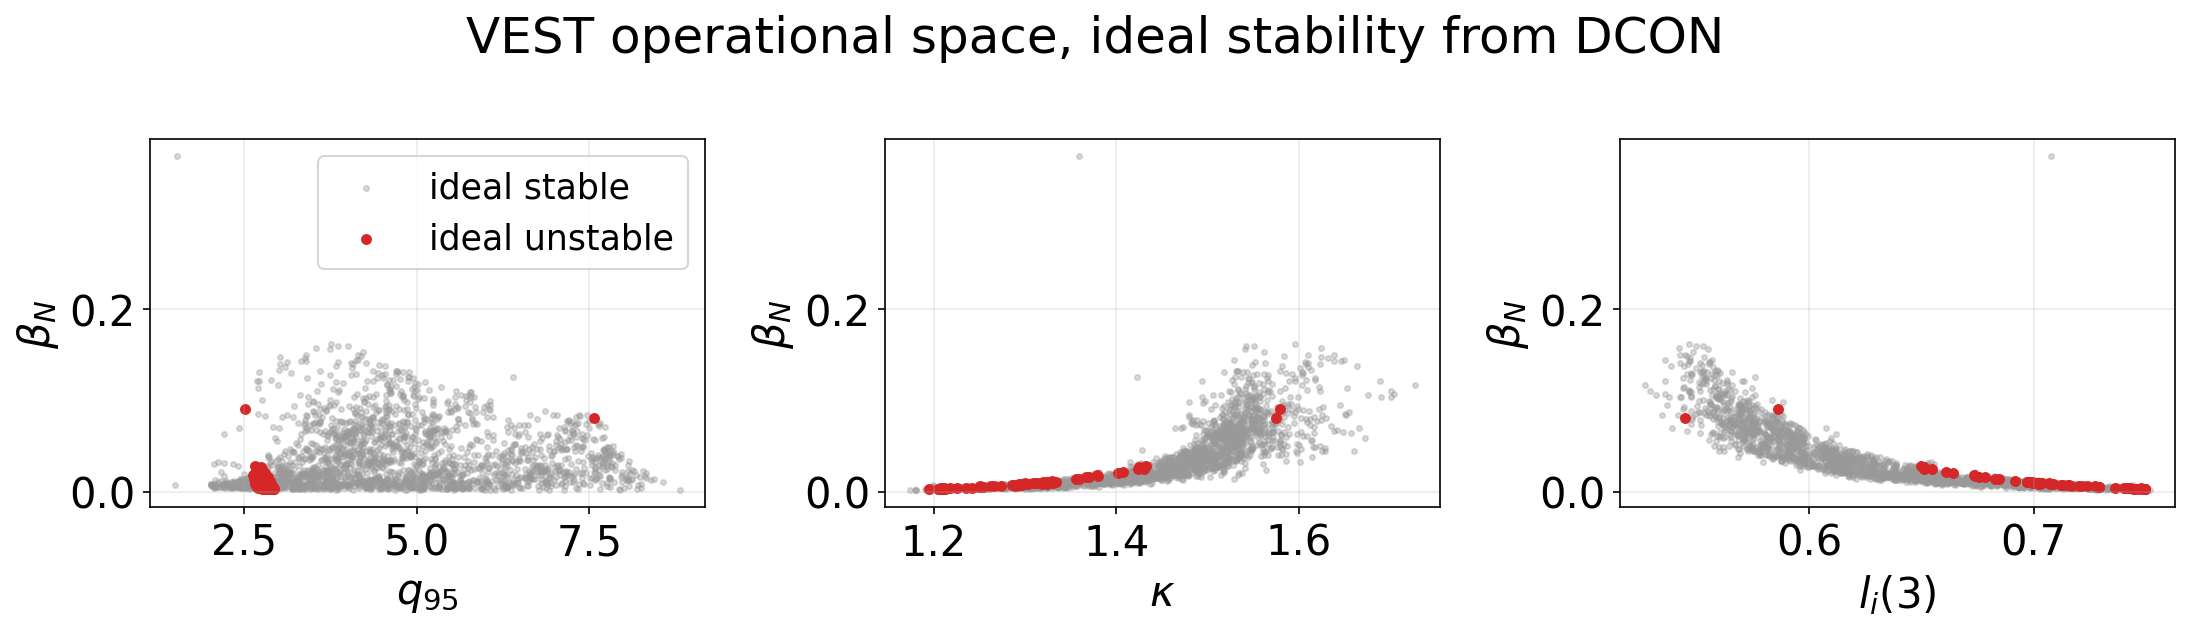

In [ ]:
# Where the unstable slices sit in the operational space the campaign covered.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
pairs = (
    ("q95", "beta_normal", r"$q_{95}$", r"$\beta_N$"),
    ("elongation", "beta_normal", r"$\kappa$", r"$\beta_N$"),
    ("li_3", "beta_normal", r"$l_i(3)$", r"$\beta_N$"),
)
for ax, (x, y, xlabel, ylabel) in zip(axes, pairs):
    stable = stability[stability["ideal_stability"] == "Stable"]
    unstable = stability[stability["ideal_stability"] == "Unstable"]
    ax.scatter(stable[x], stable[y], s=6, alpha=0.35, color="0.6", label="ideal stable")
    ax.scatter(unstable[x], unstable[y], s=18, color="tab:red", label="ideal unstable")
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.grid(alpha=0.25)
axes[0].legend(fontsize="small")
fig.suptitle("VEST operational space, ideal stability from DCON")
fig.tight_layout()
plt.show()

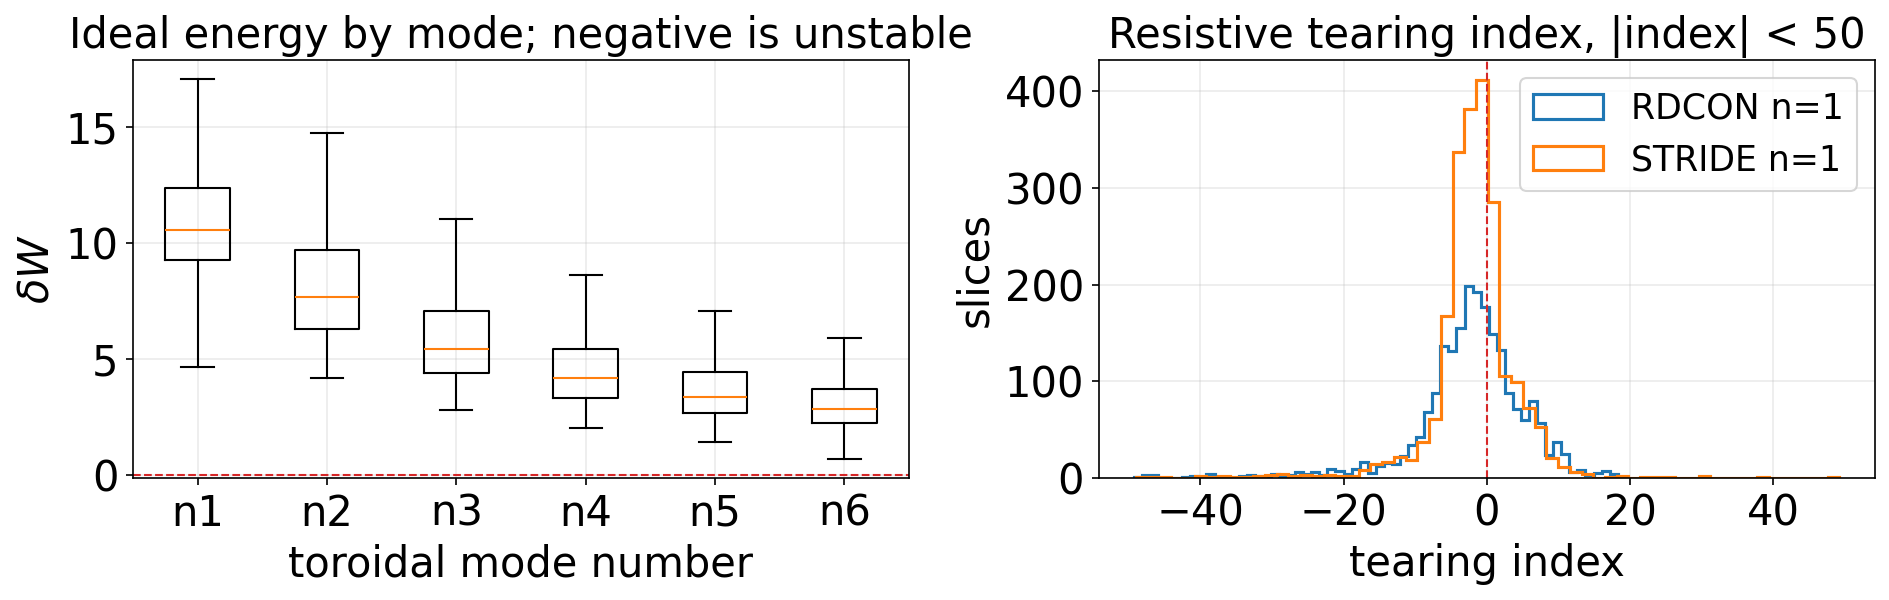

slices with delta_W(n=1) < 0: 63
slices with a positive RDCON n=1 tearing index: 797


In [ ]:
# The mode spectrum behind those labels: delta_W by toroidal mode number, and
# the tearing index that decides the resistive verdict.
modes = [f"delta_w_n{n}" for n in range(1, 7)]

fig, (ax_dw, ax_tearing) = plt.subplots(1, 2, figsize=(13, 4.4))
ax_dw.boxplot([stability[m].dropna() for m in modes], tick_labels=[m[-2:] for m in modes],
              showfliers=False)
ax_dw.axhline(0.0, color="tab:red", ls="--", lw=1.0)
ax_dw.set(xlabel="toroidal mode number", ylabel=r"$\delta W$",
          title="Ideal energy by mode; negative is unstable")
ax_dw.grid(alpha=0.25)

for column, label in (("tearing_index_rdcon_n1", "RDCON n=1"), ("tearing_index_stride_n1", "STRIDE n=1")):
    values = stability[column].dropna()
    ax_tearing.hist(values[np.abs(values) < 50], bins=60, histtype="step", lw=1.5, label=label)
ax_tearing.axvline(0.0, color="tab:red", ls="--", lw=1.0)
ax_tearing.set(xlabel="tearing index", ylabel="slices",
               title="Resistive tearing index, |index| < 50")
ax_tearing.legend(fontsize="small")
ax_tearing.grid(alpha=0.25)
fig.tight_layout()
plt.show()

print(f"slices with delta_W(n=1) < 0: {(stability['delta_w_n1'] < 0).sum()}")
print(f"slices with a positive RDCON n=1 tearing index: "
      f"{(stability['tearing_index_rdcon_n1'] > 0).sum()}")

In [ ]:
import pandas as pd

# (The delta-prime grid helper lived here; see the note below.)

In [ ]:
# Which shots the unstable slices belong to, and how concentrated they are.
ideal_unstable = stability[stability["ideal_stability"] == "Unstable"]
resistive_unstable = stability[stability["resistive_stability"] == "Unstable"]

ideal_unstable_shots = sorted(ideal_unstable["shot"].unique().tolist())
n1_resistive_unstable_shots = sorted(
    stability[stability["tearing_index_rdcon_n1"] > 0]["shot"].unique().tolist()
)

print(f"ideal-unstable slices    {len(ideal_unstable):5d} in {len(ideal_unstable_shots)} shots")
print(f"resistive-unstable slices{len(resistive_unstable):5d} in "
      f"{resistive_unstable['shot'].nunique()} shots")
print()
print("first ideal-unstable shots:", ideal_unstable_shots[:12])

ideal-unstable slices       64 in 61 shots
resistive-unstable slices 1364 in 619 shots

first ideal-unstable shots: [38324, 38692, 38693, 38694, 38695, 38699, 38748, 38750, 38766, 39613, 40246, 40249]


In [ ]:
# The unstable slices against the stable population, quantity by quantity: the
# spread that a stability limit would have to separate.
summary = []
for column in ("ip [kA]", "beta_normal", "q95", "elongation", "li_3", "beta_poloidal"):
    stable_values = stability.loc[stability["ideal_stability"] == "Stable", column]
    unstable_values = stability.loc[stability["ideal_stability"] == "Unstable", column]
    summary.append({
        "quantity": column,
        "stable median": stable_values.median(),
        "unstable median": unstable_values.median(),
        "stable p95": stable_values.quantile(0.95),
        "unstable p95": unstable_values.quantile(0.95),
    })
print(pd.DataFrame(summary).set_index("quantity").to_string(
    float_format=lambda value: f"{value:.4g}"))

               stable median  unstable median  stable p95  unstable p95
quantity                                                               
ip [kA]                 63.2             54.4         151         104.9
beta_normal          0.02265         0.008811      0.1039       0.02656
q95                    4.542            2.803       7.554         2.924
elongation             1.454            1.306       1.584          1.43
li_3                  0.6298           0.7053      0.7299        0.7493
beta_poloidal        0.00517         0.001816     0.01465       0.00379


Figure 9. Correlation of an Observed Instability with Stability Analysis 


In [ ]:
from omas import ODS

import numpy as np
import matplotlib.pyplot as plt

import vaft
from vaft.data.resources import data_path
from vaft.machine_mapping.magnetics import magnetics
from vaft.process.fluctuation import compute_spectrogram
from vaft.process.signal_processing import fir_filter

# The raw archive packaged with VAFT, so this figure is reproducible without the
# VEST raw database: shot 45531, mapped through the same magnetics path the
# fluctuation analysis uses.
FLUCTUATION_SHOT = 45531
fixture = data_path("legacy/shot_45531.json.gz")
raw_template = str(fixture.parent / "shot_{shot}.json.gz")

fluctuation_ods = ODS()
magnetics(
    fluctuation_ods, shot=FLUCTUATION_SHOT,
    tstart=0.26, tend=0.36, dt=4e-5, raw_source=raw_template,
)
print(f"shot {FLUCTUATION_SHOT}: {len(fluctuation_ods['magnetics.b_field_pol_probe'])} probes mapped")

Field 207 not found in JSON. Skipping...


No valid fields loaded from JSON for shot=45531.


Field 241 not found in JSON. Skipping...


No valid fields loaded from JSON for shot=45531.


Field 209 not found in JSON. Skipping...


...

Field 217 not found in JSON. Skipping...


No valid fields loaded from JSON for shot=45531.


Field 218 not found in JSON. Skipping...


No valid fields loaded from JSON for shot=45531.


shot 45531: 98 probes mapped


In [ ]:
# One Mirnov channel, band-limited with the library's linear-phase filter before
# the transform: a phase-preserving filter is what a mode-number reading needs,
# and vaft.process.signal_processing.fir_filter is where that design now lives.
# Channels are chosen by carrying data, not by position -- the equilibrium
# Mirnovs share the array with the fast fluctuation ones and store no voltage.
# The fast Mirnovs share the probe array with the equilibrium ones, which carry
# no voltage at all, so select by name *and* by carrying samples.
probe_name = None
for index in range(len(fluctuation_ods["magnetics.b_field_pol_probe"])):
    name = str(fluctuation_ods[f"magnetics.b_field_pol_probe.{index}.name"])
    samples = fluctuation_ods.get(
        f"magnetics.b_field_pol_probe.{index}.voltage.data", None
    )
    if name.startswith("OutMirnov") and samples is not None and np.size(samples) > 1000:
        probe, probe_name = index, name
        break
if probe_name is None:
    raise RuntimeError("no fast Mirnov channel with voltage samples in this archive")

base = f"magnetics.b_field_pol_probe.{probe}.voltage"
time = np.asarray(fluctuation_ods[f"{base}.time"], dtype=float)
voltage = np.asarray(fluctuation_ods[f"{base}.data"], dtype=float)
rate = 1.0 / np.median(np.diff(time))

band_limited = fir_filter(voltage, (2.0e3, 1.0e5), rate, kind="bandpass")
spectrogram = compute_spectrogram(time, band_limited, nperseg=2048)
print(f"{probe_name}: {time.size} samples at {rate/1e6:.2f} MS/s -> "
      f"{spectrogram.frequency.size} frequencies x {spectrogram.time.size} bins")

OutMirnov_45_L1-01: 199999 samples at 2.00 MS/s -> 1025 frequencies x 194 bins


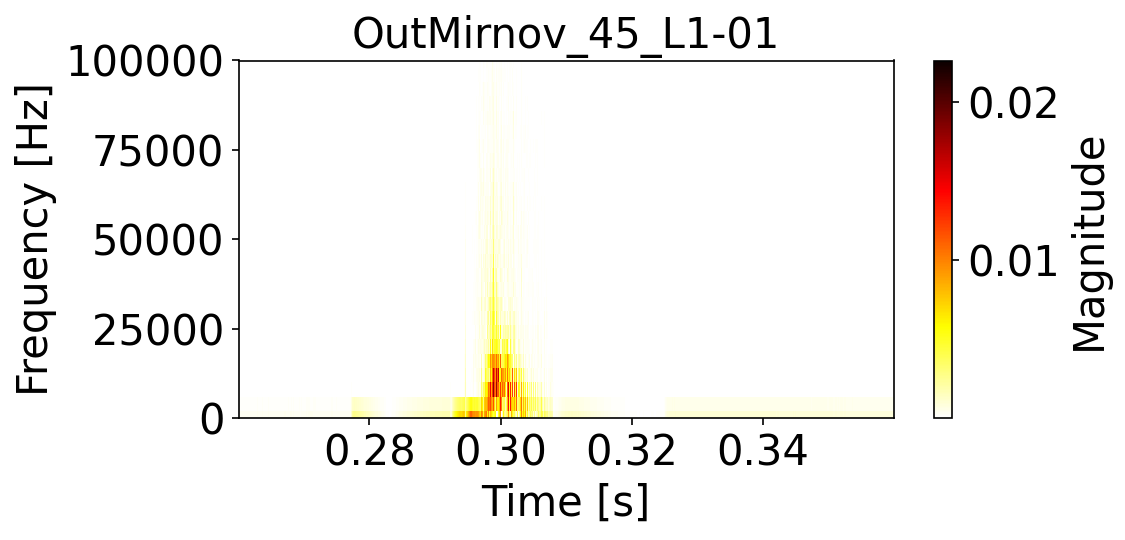

(<Figure size 1200x600 with 2 Axes>,
 <Axes: title={'center': 'OutMirnov_45_L1-01'}, xlabel='Time [s]', ylabel='Frequency [Hz]'>)

In [ ]:
# The canonical renderer over the same ODS and the same channel: no local
# pcolormesh, no local colour-limit handling, and the title comes from the data.
# A spectrogram is a single-channel view, so it takes `channel=` rather than the
# `selection=` vocabulary the multi-channel plots use.
vaft.omas.plot_mirnov_spectrogram(
    fluctuation_ods, channel=probe, max_frequency=1.0e5, show=True
)

In [ ]:
print('Skipped operation-stability analysis function/call: external /srv ODS, raw DB, and Excel inputs are not available in this environment.')


Skipped operation-stability analysis function/call: external /srv ODS, raw DB, and Excel inputs are not available in this environment.


In [ ]:
# The lists the later sections refer to, from the same table.
n2_resistive_unstable_shots = sorted(
    stability[stability["tearing_index_rdcon_n2"] > 0]["shot"].unique().tolist()
)
print(f"ideal unstable        {len(ideal_unstable_shots):4d} shots")
print(f"resistive n=1 unstable{len(n1_resistive_unstable_shots):4d} shots")
print(f"resistive n=2 unstable{len(n2_resistive_unstable_shots):4d} shots")

ideal unstable          61 shots
resistive n=1 unstable 390 shots
resistive n=2 unstable  69 shots


In [ ]:
# The vacuum-field panel here used to plot arrays of zeros standing in for a
# calculation that could not run, which reads as a result and is not one. The
# real calculation is offline and lives in
# `eddy_current_calculation_and_startup_analysis.ipynb`, which solves the
# passive-circuit response and checks the field it produces against the flux
# loops before reading anything off it.
print("Vacuum-field figure: see eddy_current_calculation_and_startup_analysis.ipynb")

Vacuum-field figure: see eddy_current_calculation_and_startup_analysis.ipynb


In [ ]:
print('Skipped batch operation-stability figure export: external Excel/ODS inputs are not available in this environment.')


Skipped batch operation-stability figure export: external Excel/ODS inputs are not available in this environment.


In [ ]:
print('Skipped external VFIT_tools-based operation analysis helper definitions in this environment.')


Skipped external VFIT_tools-based operation analysis helper definitions in this environment.
